# Estimate recursive calls to fibonacci naive function

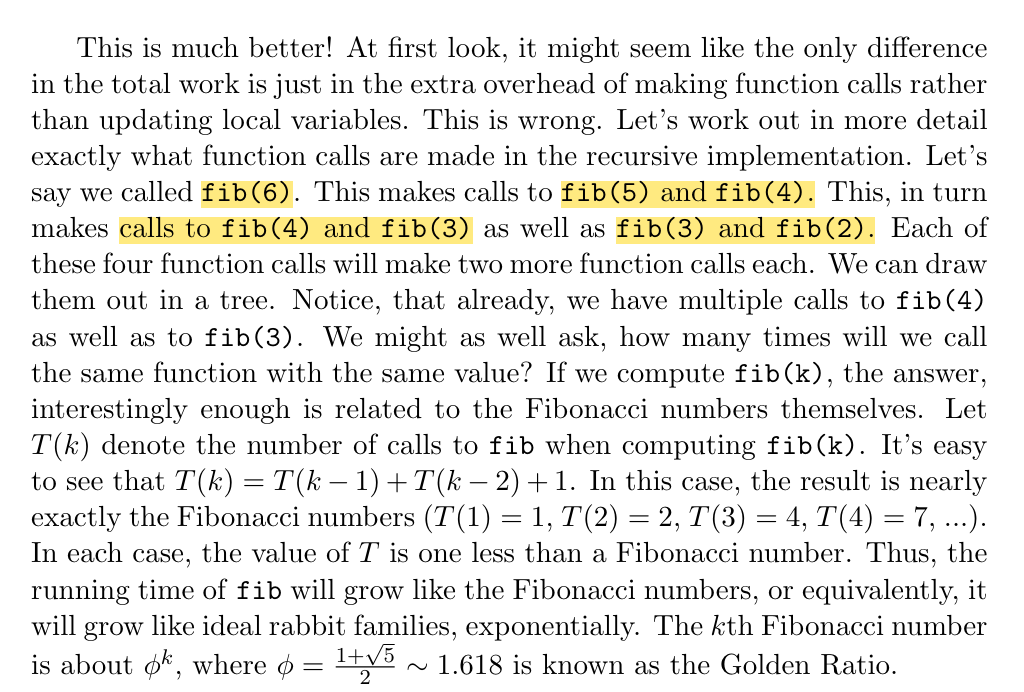
Reading the piece above, I want to investigate the exact form of the number of times fib(n) gets called.

Let's estimate $T(k)$, the number of function calls made by calling the naive fibonacci recursive function $F(k)$ to compute the k-th fibonacci number. 

In [13]:
# generate here for i ... the fibonacci and the number of calls since we know the relationship

def fib(n):
    if type(n) is not int:
        raise TypeError("n is not an integer")
    if n == 0 or n == 1:
        return 1
    else:
        return fib(n-1) + fib(n-2)

def num_calls(n):
    if type(n) is not int:
        raise TypeError("n is not an integer")
    if n == 0 or n == 1:
        return 1
    else:
        return num_calls(n-1) + num_calls(n-2) + 1

space = "    "
print('ii'+ space + 'fib(ii)' + space + 'num_calls(ii)')

for ii in range(30):
    print(str(ii) + space * 2 + str(fib(ii)) + space * 3+ str(num_calls(ii)))



ii    fib(ii)    num_calls(ii)
0        1            1
1        1            1
2        2            3
3        3            5
4        5            9
5        8            15
6        13            25
7        21            41
8        34            67
9        55            109
10        89            177
11        144            287
12        233            465
13        377            753
14        610            1219
15        987            1973
16        1597            3193
17        2584            5167
18        4181            8361
19        6765            13529
20        10946            21891
21        17711            35421
22        28657            57313
23        46368            92735
24        75025            150049
25        121393            242785
26        196418            392835
27        317811            635621
28        514229            1028457
29        832040            1664079


To the trained eye, it's evident that 
$$
    T(n) = 2 F(n) - 1
$$
Through Binet's formula
$$
    F_n = \frac{1}{\sqrt{5}} \phi^n - \frac{1}{\sqrt{5}} \psi^n
$$
with $\phi = \frac{1 + \sqrt{5}}{2} \approx 1.618...$ being the golden number, and $\phi = \frac{1 - \sqrt{5}}{2} \approx 0.618...$. Since $\frac{1}{\sqrt{5}} \psi^n \leq \frac{1}{\sqrt{5}}  < 0.5$, the second term is adding a fractional part. The nearest integer to $F_n$ is (with error at most 1, possible only for very small $n$ values)
$$
\lfloor F_n \rfloor = \lfloor \frac{1}{\sqrt{5}} \phi^n \rfloor
$$
Therefore one can estimate the number of recursive calls as
$$
    T(n) = \frac{2}{\sqrt{5}} \phi^n - 1
$$
which is exponential.

In [21]:
from math import sqrt
import numpy as np
phi = (1+sqrt(5))/2
psi = 1 - phi
prefactor = 2/sqrt(5)
end = 30
exponents = np.arange(end)

estimate_tn = (prefactor* phi**exponents - 1)
correct_tn = (prefactor * (phi**exponents - psi**exponents) - 1)

for ii in range(end):
    print(ii, space, estimate_tn[ii], space, correct_tn[ii])



0      -0.10557280900008414      -1.0
1      0.44721359549995787      1.0
2      1.3416407864998736      1.0
3      2.788854381999832      3.0
4      5.130495168499706      5.000000000000001
5      8.91934955049954      9.000000000000002
6      15.049844718999246      15.000000000000004
7      24.969194269498786      25.000000000000004
8      41.01903898849803      41.00000000000001
9      66.98823325799682      67.00000000000001
10      109.00727224649486      109.00000000000003
11      176.9955055044917      177.00000000000006
12      287.0027777509866      287.0000000000001
13      464.99828325547827      465.0000000000001
14      753.0010610064649      753.0000000000003
15      1218.9993442619432      1219.0000000000007
16      1973.0004052684083      1973.000000000001
17      3192.9997495303514      3193.000000000002
18      5167.00015479876      5167.000000000004
19      8360.999904329112      8361.000000000005
20      13529.000059127871      13529.00000000001
21      21890.99996

The agreement with the simulation at the beginning of the notebook is near perfect, but the indexes are shifted by 1

## Proving $T(n) = 2 F(n) - 1$
Once we infer the relationship, it's easy to prove it by induction.
$$
    n = 0: T(0) = 2 F(0) - 1 = 1
$$
Assuming $T(k) = 2 F(k) - 1$ holds for $k < n$,
$$
    T(n + 1) = T(n) + T(n-1) + 1 = 2 F(n) - 1 + 2 F(n-1) - 1 + 1 = 2 (F(n) + F(n-1)) - 1 = 2 F(n+1) - 1 \;\;\blacksquare
$$

# Recursion
Finding the gcd. We can write (WLOG $b\geq a$)
$$
    b = qa + r 
$$
$p | b \iff p | (qa + r)$
Since we want to find the gcd, we are looking for primes in common between $a$ and $b$. If $p$ is a common factor, then $p | a$ too, implying
$$
    p | r \implies \text{gcd}(a,b) = \text{gcd}(a,r)
$$
(To be pedantic, we have to prove that, in the other direction, $p|a, p|r \implies p|(qa + r) = b$.)
Therefore, we can keep descending until we reach the pair $(0, \text{gcd}(a,b))$ because $0 \leq r < a$.

In [23]:
def gcd(a,b):
    # swap to go to wlog case
    if a > b:
        a,b = b,a
    # base case/termination
    if a == 0:
        return b
    # calculate the rest
    return gcd(a, b%a)

gcd(10,20)

10